## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [1]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [3]:

element = 'Eu'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [4]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[0.3835,
 0.3947,
 0.4178,
 0.4467,
 0.4788,
 0.5127,
 0.549,
 0.5878,
 0.6267,
 0.6655,
 0.705,
 0.7456,
 0.7891,
 0.8367,
 0.8908,
 0.9518,
 1.0175,
 1.0891,
 1.1683,
 1.2554,
 1.3527,
 1.4601,
 1.577,
 1.7028,
 1.8355,
 1.9735,
 2.1159,
 2.2636,
 2.4192,
 2.5867,
 2.7647,
 2.9543,
 3.1476,
 3.3424,
 3.5383,
 3.734,
 3.9294,
 0.3609,
 0.3809,
 0.4048,
 0.4329,
 0.4635,
 0.4951,
 0.53,
 0.5681,
 0.6072,
 0.646,
 0.6849,
 0.726,
 0.7688,
 0.8148,
 0.8654,
 0.9228,
 0.9864,
 1.0551,
 1.13,
 1.2136,
 1.306,
 1.4074,
 1.5168,
 1.6404,
 1.7693,
 1.9034,
 2.0437,
 2.1899,
 2.3425,
 2.5038,
 2.6779,
 2.8638,
 3.0576,
 3.2559,
 3.4462,
 3.629,
 3.8237,
 4.0292,
 0.02942,
 0.0314,
 0.03268,
 0.03512,
 0.03669,
 0.03885,
 0.04071,
 0.04194,
 0.04449,
 0.04726,
 0.04948,
 0.05118,
 0.05395,
 0.05662,
 0.05894,
 0.06208,
 0.06425,
 0.06843,
 0.07005,
 0.07561,
 0.08161,
 0.08832,
 0.09656,
 0.10643,
 0.11821,
 0.12966,
 0.1375,
 0.1435,
 0.15117,
 0.15756,
 0.16585,
 0.17122,
 0.18807,
 0.19263,


In [5]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [6]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [7]:

Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [8]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = data['Temp'].values
cp = data['Heat capacity at constant pressure Cp: J/K/mol'].values



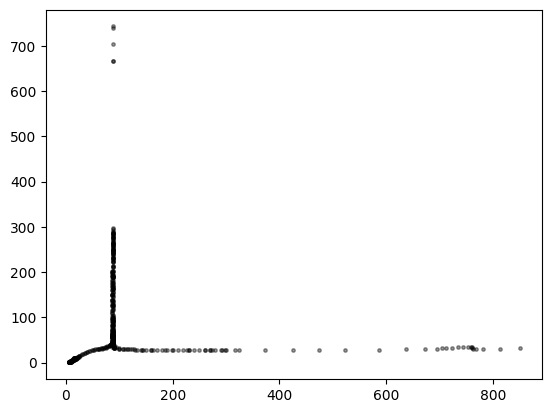

In [9]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [10]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
initial_5params = [300, 1e-3, 0.01, 800, 300]
#initial_5params = [225, 1e-4, 1e-3, 150, 350]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [11]:
from espei.pureElement import log_probability

In [12]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 4000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [02:11<00:00, 30.37it/s]


State([[ 9.78025313e+01  6.51850603e-06  1.16441784e-03 -6.07284241e+04
  -5.78352943e+04]
 [ 9.71645857e+01  4.42606776e-06  1.15640453e-03 -6.11805731e+04
  -5.86871951e+04]
 [ 9.70142737e+01  1.89591790e-05  1.14323783e-03 -6.18557006e+04
  -4.66550391e+04]
 [ 9.77610598e+01  1.97642091e-07  1.16349882e-03 -6.07798410e+04
  -5.76685256e+04]
 [ 9.80610236e+01  1.88835106e-06  1.15337688e-03 -6.12313517e+04
  -6.13124914e+04]
 [ 9.76588731e+01  4.74212005e-06  1.15755531e-03 -6.10650411e+04
  -5.92179453e+04]
 [ 9.69688928e+01  8.86874705e-06  1.15774121e-03 -6.10628049e+04
  -6.08694443e+04]
 [ 9.77066923e+01  4.90970047e-06  1.16253365e-03 -6.09211188e+04
  -5.96243700e+04]
 [ 9.80102859e+01  1.94889704e-06  1.16042495e-03 -6.09333597e+04
  -6.10087598e+04]
 [ 9.74200815e+01  5.84390992e-06  1.15912782e-03 -6.09808101e+04
  -5.96119394e+04]
 [ 9.73091249e+01  3.68700276e-06  1.16589426e-03 -6.06415661e+04
  -5.28596994e+04]
 [ 9.74312504e+01  1.86333170e-06  1.16522876e-03 -6.068173

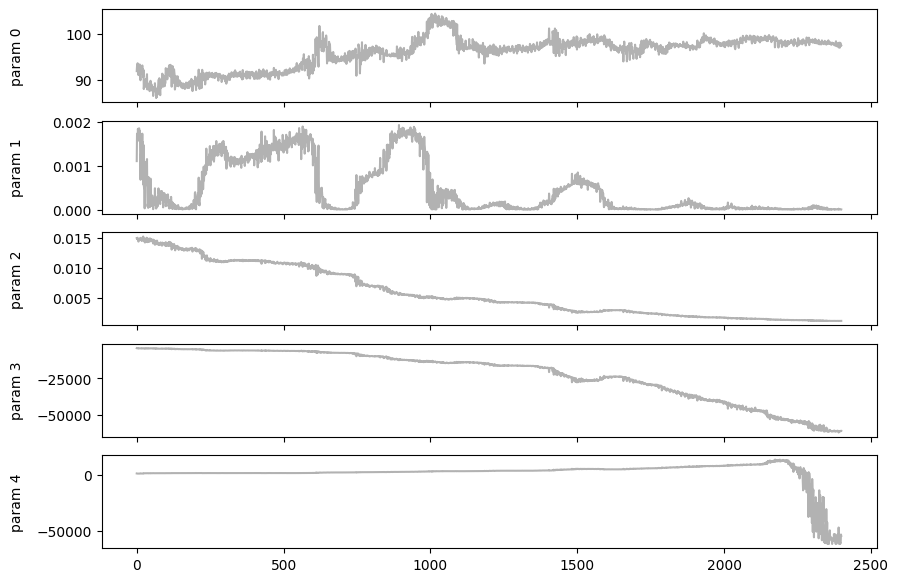

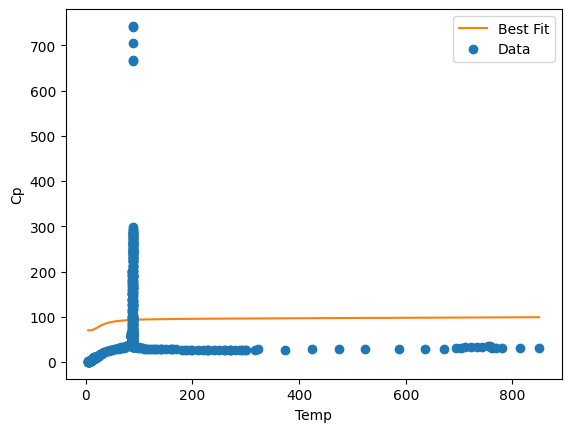

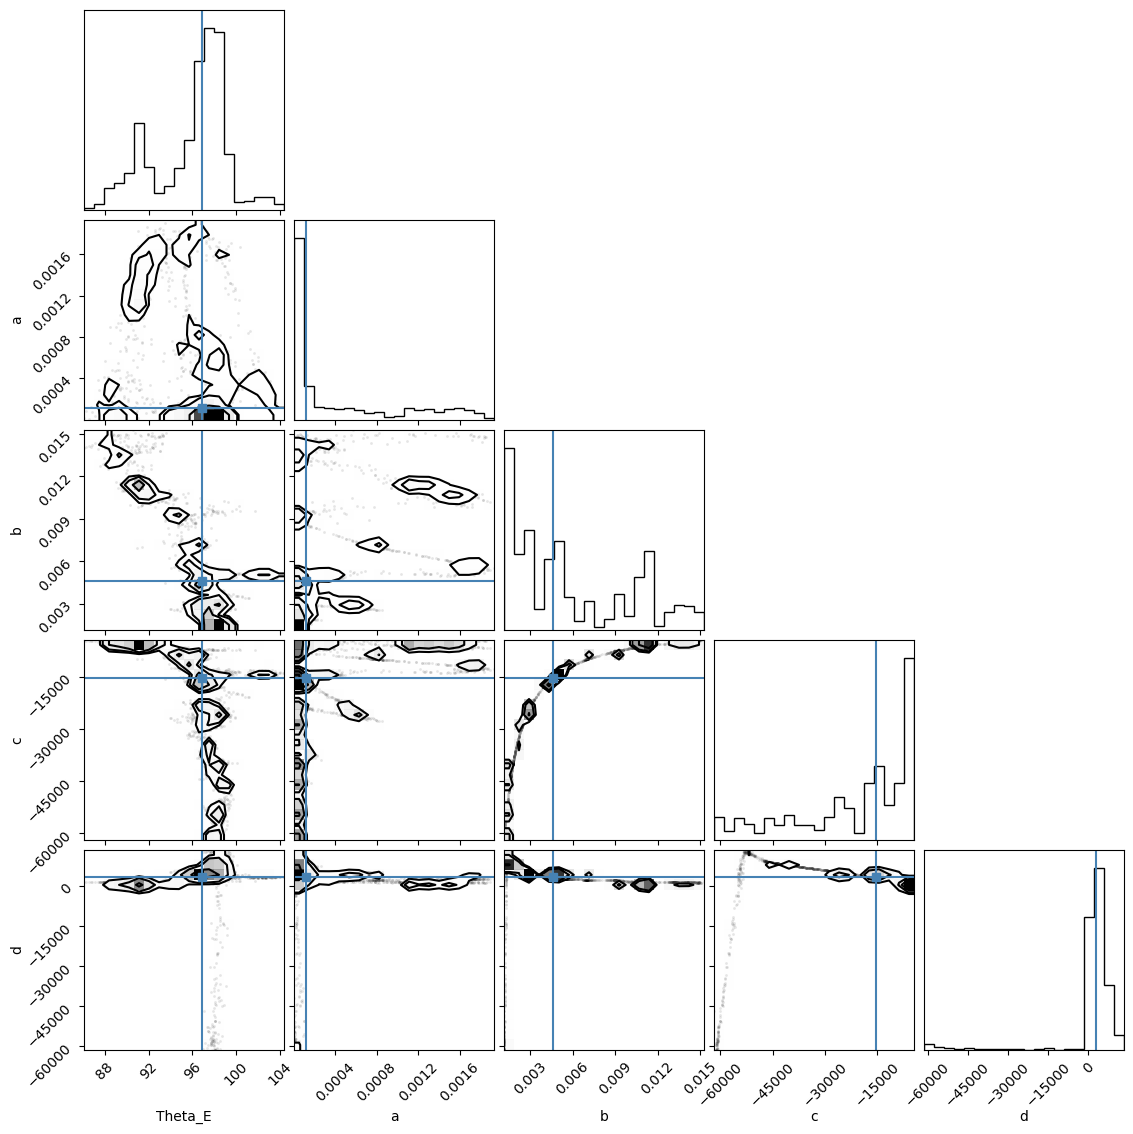

In [13]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


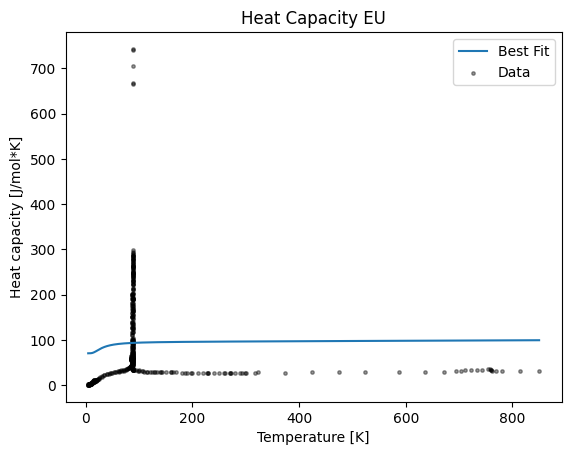

In [14]:
# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [15]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([ 9.68995583e+01,  1.13726179e-04,  4.58498042e-03, -1.53157764e+04,
        3.19477257e+03])

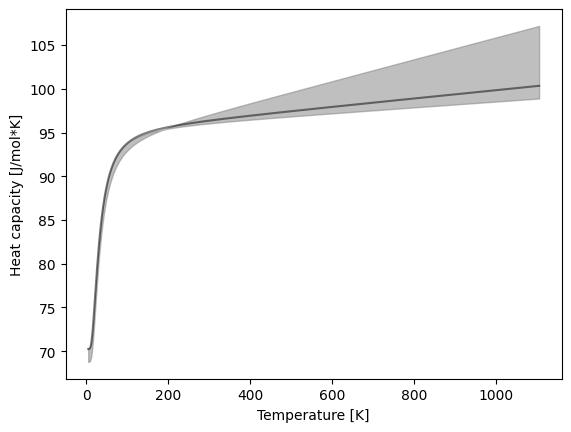

In [16]:
best_params = np.median(samples, axis=0)
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [17]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [18]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 3.375079296913329
Standard deviation of a: 0.0005780379019725763
Standard deviation of b: 0.004197951101010248
Standard deviation of c: 16717.53895253664
Standard deviation of d: 11222.956857816955


In [19]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[2.79899766e+01 9.99959300e-02 6.51842251e-15]
 [2.79935793e+01 9.99999750e-02 1.91074644e-15]
 [2.79497202e+01 9.99998758e-02 4.05599410e-16]
 [2.83377251e+01 9.99997151e-02 2.46899514e-16]
 [2.82189447e+01 9.99996917e-02 5.22860944e-16]
 [2.78577261e+01 9.99993412e-02 2.01855652e-15]
 [2.82774863e+01 9.99998538e-02 8.05900752e-17]
 [2.80489644e+01 9.99999242e-02 5.05553079e-15]
 [2.80881672e+01 9.99961098e-02 2.98887957e-16]
 [2.79269538e+01 9.99999748e-02 5.24322131e-15]
 [2.78593611e+01 9.99976834e-02 1.70220159e-15]
 [2.80191084e+01 9.99997725e-02 5.17980222e-15]
 [2.80622852e+01 9.99997316e-02 5.27026843e-15]
 [2.80579539e+01 9.99988621e-02 4.29471073e-15]
 [2.80702796e+01 9.99993887e-02 3.85000422e-15]
 [2.78514272e+01 9.99999572e-02 9.11734338e-16]
 [2.81248364e+01 9.99996493e-02 1.35803139e-15]
 [2.79361998e+01 9.99998025e-02 3.15748340e-15]
 [2.81508750e+01 9.99997626e-02 1.39512774e-15]
 [2.80682666e+01 9.99998654e-02 1.59005105e-15]
 [2.79644404e+01 9.99991757e-02 9.

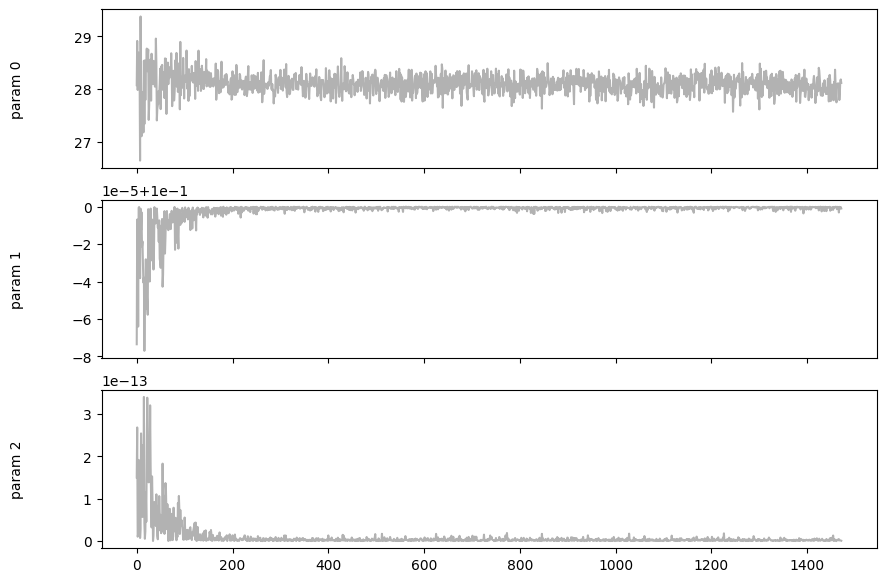

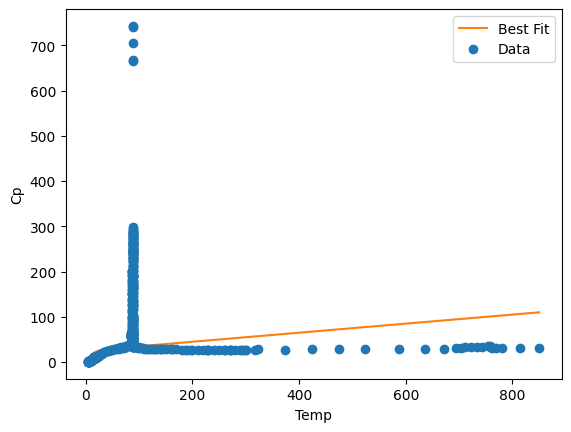

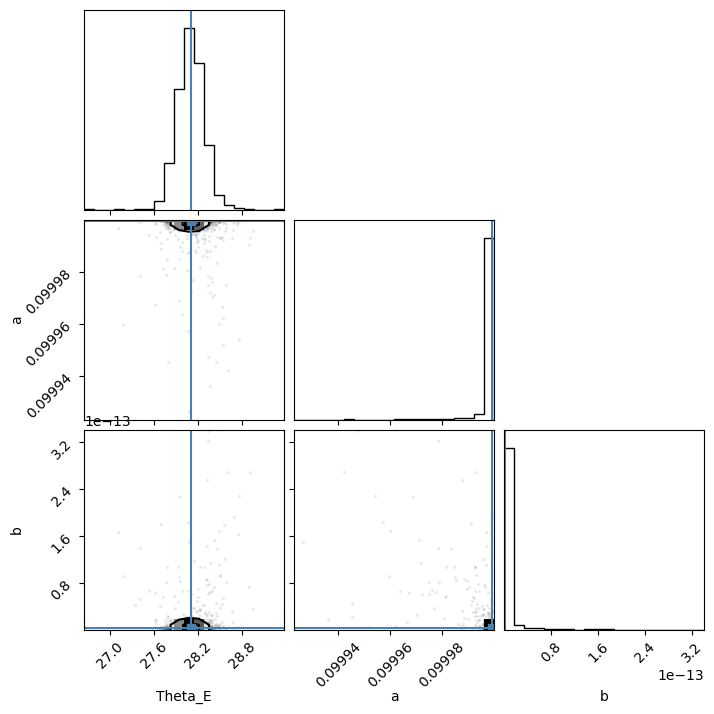

In [20]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = np.median(samples2, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


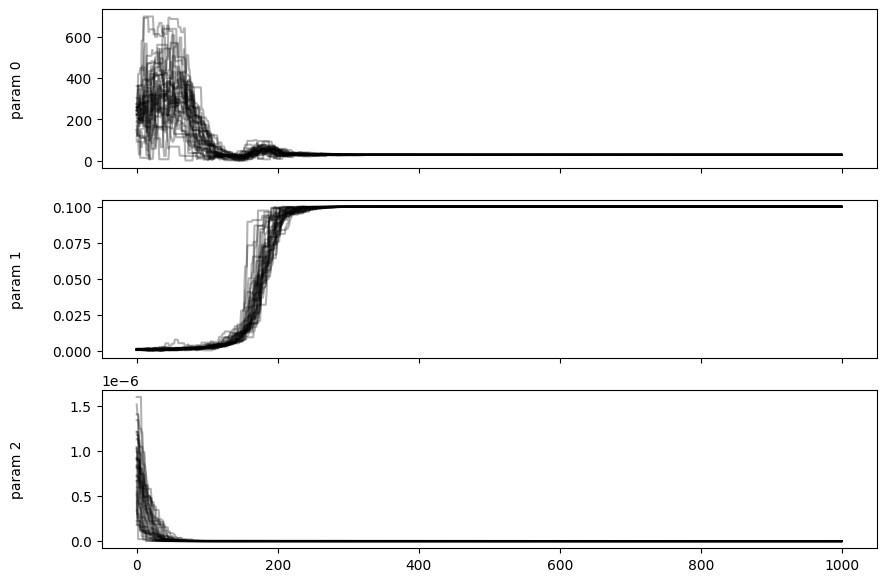

In [21]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([2.81006104e+01, 9.99994214e-02, 2.34811505e-15])

In [23]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[2.79659748e+01 9.99995825e-02 2.52541242e-09]
 [2.83998089e+01 9.99993766e-02 2.56723294e-09]
 [2.80717090e+01 9.99989326e-02 1.94395219e-09]
 [2.80478586e+01 9.99977931e-02 1.74520357e-09]
 [2.82719244e+01 9.99980721e-02 2.81135990e-09]
 [2.80486497e+01 9.99982217e-02 1.81034048e-09]
 [2.80684033e+01 9.99982556e-02 1.36310634e-09]
 [2.80748137e+01 9.99998410e-02 2.14928120e-09]
 [2.81734841e+01 9.99999056e-02 1.35572918e-09]
 [2.81849428e+01 9.99998740e-02 2.40224959e-09]
 [2.84251001e+01 9.99984685e-02 2.02204345e-09]
 [2.83252522e+01 9.99995920e-02 2.12045537e-09]
 [2.84011300e+01 9.99998006e-02 1.67160334e-10]
 [2.79301763e+01 9.99997904e-02 4.87531441e-10]
 [2.80866397e+01 9.99998826e-02 9.76707073e-10]
 [2.82363711e+01 9.99998010e-02 8.90046417e-10]
 [2.81266792e+01 9.99998379e-02 2.59441646e-09]
 [2.82418572e+01 9.99989546e-02 4.82086209e-10]
 [2.81229012e+01 9.99990289e-02 4.98909131e-09]
 [2.85069871e+01 9.99997603e-02 4.05569153e-10]
 [2.81127854e+01 9.99989652e-02 1.

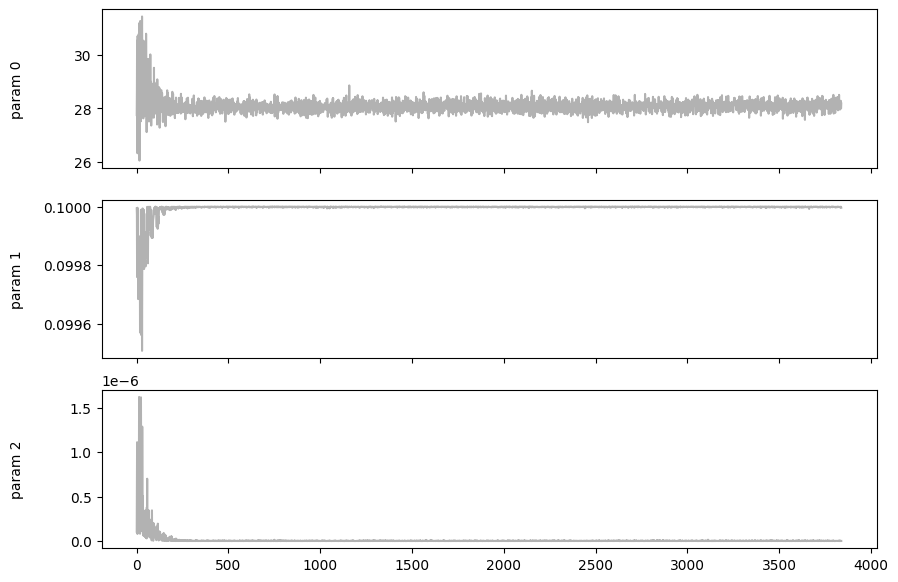

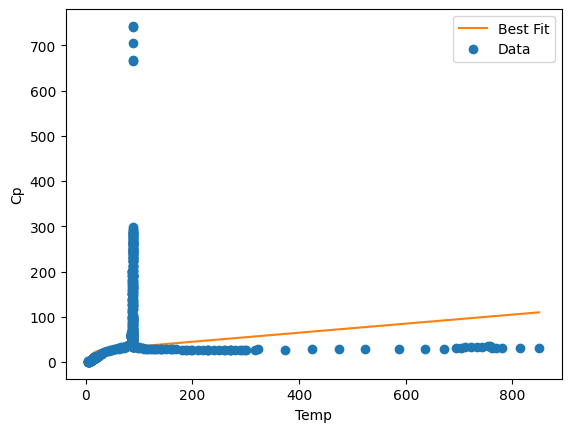

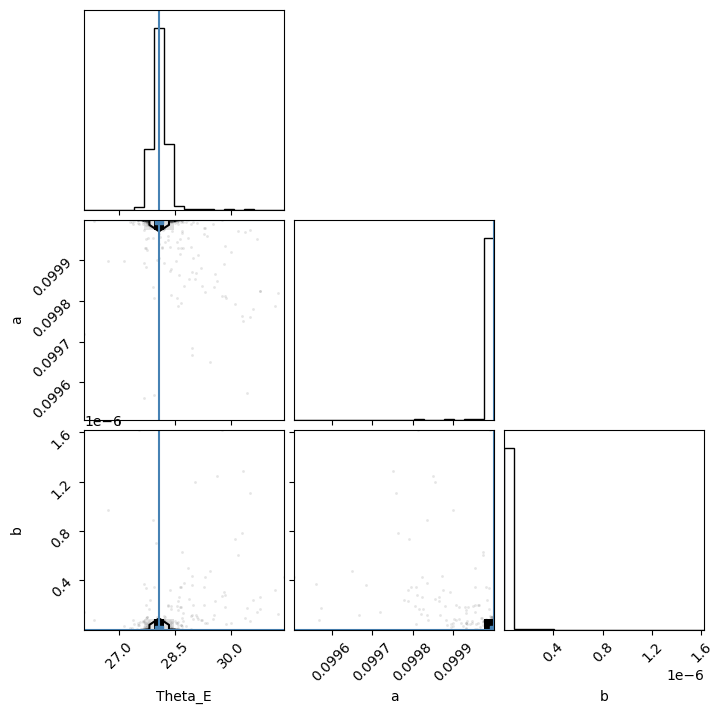

In [24]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


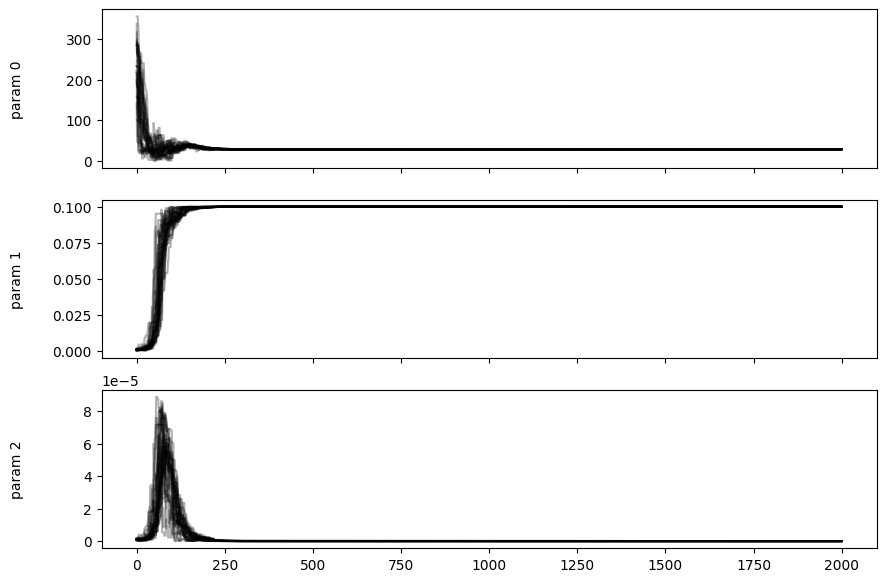

In [25]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [26]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[2.80762245e+01 9.99994274e-02 1.59451687e-09]


<IPython.core.display.Math object>

...

[2.81006104e+01 9.99994214e-02 2.34811505e-15]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[ 9.68995583e+01  1.13726179e-04  4.58498042e-03 -1.53157764e+04
  3.19477257e+03]


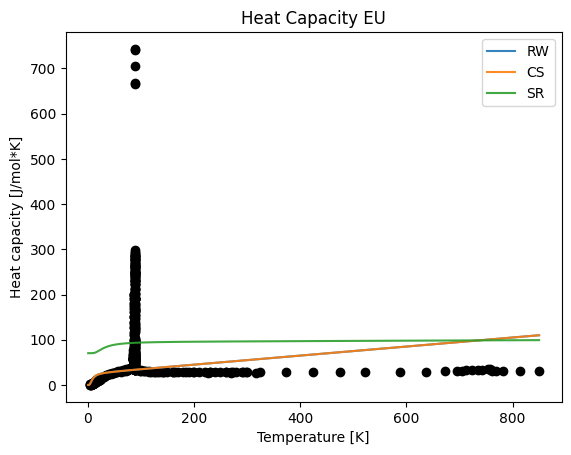

In [27]:
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [28]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [29]:
print(RW[0],CS[0],SR[0])

0.8314221849692224 0.8314221198803794 583.8880598347168


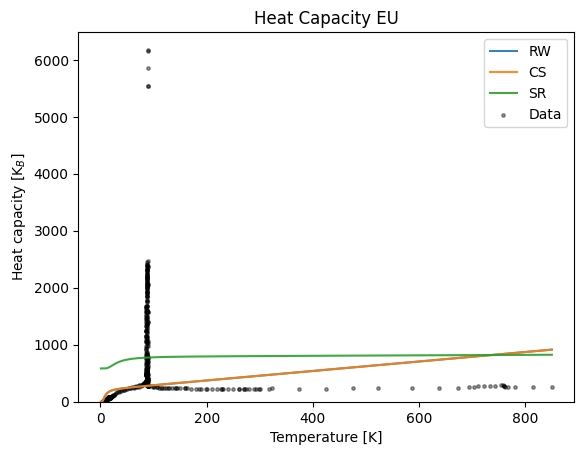

In [30]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

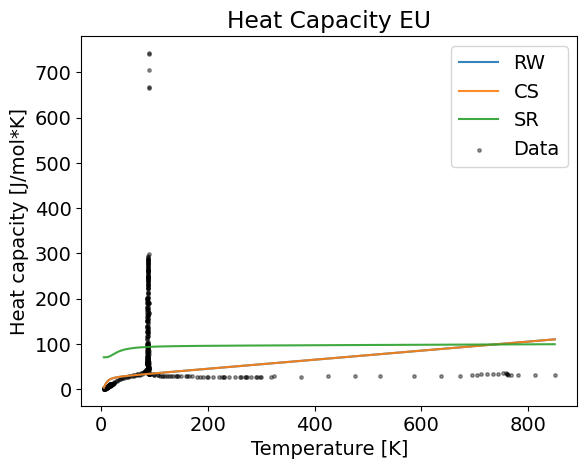

In [31]:
plt.rcParams.update({'font.size': 14})
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [32]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


ConditionError: None of the passed phases (['FCC_A1']) are active. List of possible phases: ['BCC_A2', 'LIQUID'].

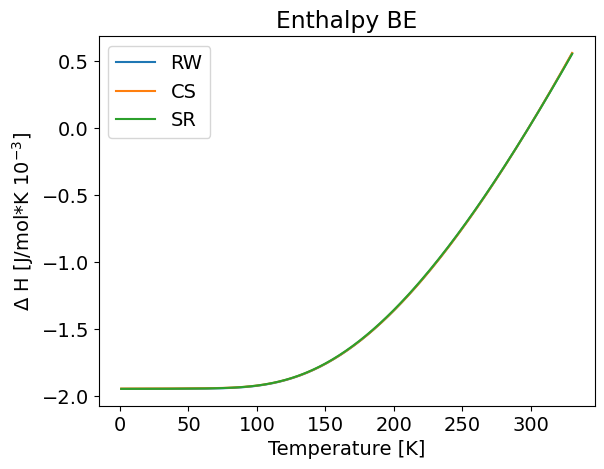

In [ ]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

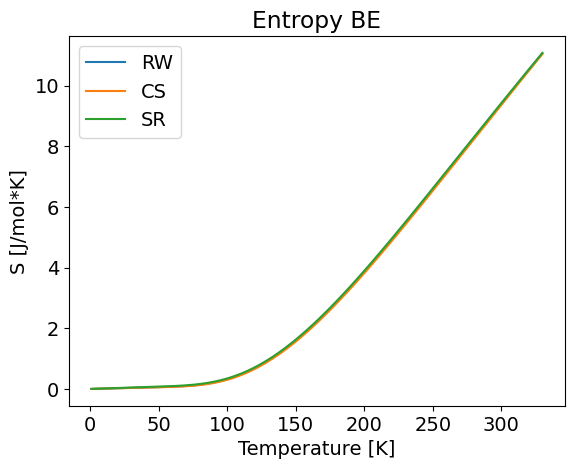

In [ ]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [ ]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [ ]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 369
aic2: 18.60158687043404
correction:  0.06575342465753424
k= 3 n= 369
aic2: 18.755857970186472
correction:  0.06575342465753424
k= 5 n= 369
aic2: 22.10074556787289
correction:  0.1652892561983471


In [ ]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 18.667340295091574
AICC_CS: 18.821611394844005
AICC_SR: 22.266034824071237
